**Projekt z przedmiotu:** "Wielowymiarowa analiza danych" |
**Grupa:** IZIwE2 2.1 IP

---

**Temat:** Analiza plam slonecznych |
**Autor:** Kondraciuk Jakub, 98038 |
**Data wykonania:** 13.01.2026r.

**1. Import bibliotek**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.fft import fft, fftfreq

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14,6)
plt.rcParams['font.size'] = 12

**Komentarz:**
1. Import bibliotek:
    * pandas - obsluga danych w formie DataFrame
    * numpy - operacje numeryczne
    * matplotlib.pyplot - wykresy statyczne
    * seaborn - zaawansowane wykresy statyczne
    * warnings - kontrola wyświetlania ostrzeżeń
    * scipy.stats - funkcje statystyczne
    * scipy.fft - szybka transformata Fouriera
2. Początkowe ustawienia:
    * wyłączenie wszystkich ostrzeżeń
    * ustawienie stylu wykresów Seaborn

**2. Wczytanie danych**

In [30]:
from google.colab import drive

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/SN_d_tot_V2.0.txt'

df = pd.read_csv(file_path, delim_whitespace=True, header=None,
                 names=['Year', 'Month', 'Day', 'DecYear', 'Sunspots', 'Error', 'Observations'],
                 on_bad_lines='skip')

print(f"Wczytano {len(df)} wierszy")

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Wczytano 75787 wierszy
   Year  Month  Day   DecYear  Sunspots  Error  Observations
0  1818      1    1  1818.001        -1   -1.0             0
1  1818      1    2  1818.004        -1   -1.0             0
2  1818      1    3  1818.007        -1   -1.0             0
3  1818      1    4  1818.010        -1   -1.0             0
4  1818      1    5  1818.012        -1   -1.0             0


**Komentarz:**
1. Import biblioteki google.colab
2. Połączenie z Google Drive
3. Liczba wczytanych wierszy = *75787*
4. Pierwsze 5 wierszy to pierwsze 5 dni stycznia 1818 roku

**3. Preprocessing danych**

In [31]:
missing_count = (df['Sunspots'] == -1).sum()
print(f"Brakujące dane: {missing_count} wierszy")

Brakujące dane: 3247 wierszy


**Komentarz:**
1. Zbiór zawiera brakujące dane w kolumnie "Sunspots", więc musimy to odpowiednio obsłużyć
2. Liczba brakujących wierszy = *3247*

In [32]:
df['Sunspots_orig'] = df['Sunspots'].copy()
df['Sunspots'] = df['Sunspots'].replace(-1, np.nan)
df['Sunspots_interp'] = df['Sunspots'].interpolate(method='linear')

**Komentarz:**
1. Zamieniamy brakujące wartości na NaN i uzupełnienie ich poprzez interpolację liniową między dostępnymi punktami

In [33]:
df['Date'] = pd.to_datetime(df[['Year','Month','Day']], errors='coerce')

**Komentarz:**
1. Tworzenie nowej kolumny z pełną datą

In [35]:
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

**Komentarz:**
1. Sortowanie wierszy według kolumny Date od najwcześniejszej do najpóźniejszej daty

In [36]:
print(f"Brakujące wartości po zamianie i interpolacji: {df['Sunspots_interp'].isna().sum()}")
print(f"Zakres dat: {df['Date'].min()} do {df['Date'].max()}")

Brakujące wartości po zamianie i interpolacji: 7
Zakres dat: 1818-01-01 00:00:00 do 2025-06-30 00:00:00


**Komentarz:**
1. Wyświetlenie podstawowych informacji po obróbce danych:
    * Brakujące wartości = *7*
    * Zakres dat = *1818-01-01 00:00:00 - 2025-06-30 00:00:00*

**4. Wizualizacja szeregów czasowych**

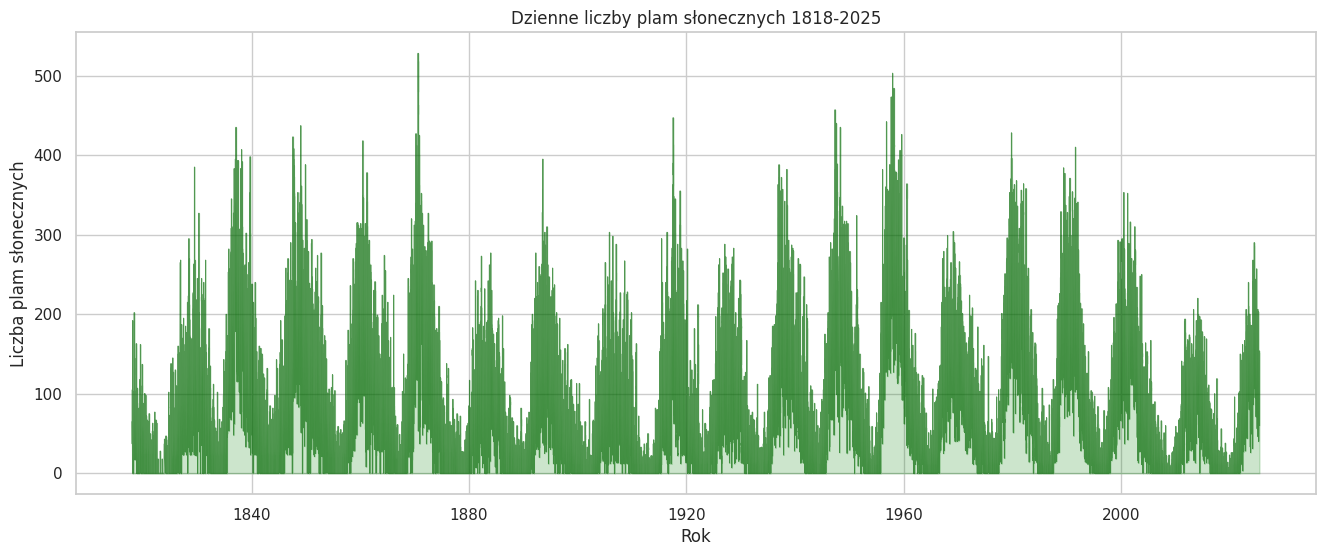

In [37]:
plt.figure(figsize=(16,6))
plt.plot(df['Date'], df['Sunspots_interp'], color='darkgreen', alpha=0.6, lw=0.7)
plt.fill_between(df['Date'], 0, df['Sunspots_interp'], color='green', alpha=0.2)
plt.title("Dzienne liczby plam słonecznych 1818-2025")
plt.xlabel("Rok")
plt.ylabel("Liczba plam słonecznych")
plt.show()

**Komentarz:**
1. Narysowanie wykresu szeregów czasowych dziennych liczb plam słonecznych
2. Wykres:
    * Wykres ilustruje zmienność aktywności słońca mierzoną poprzez liczbę plam słonecznych obserwowanych każdego dnia w okresie 1818–2025
    * Oś X - przedział czasowy od 1818 do 2025 roku
    * Oś Y - pokazuje dzienną liczbę plam słonecznych

**5. Statystyki opisowe**

Średnia             : 83.71
Mediana             : 64.00
Odchylenie std      : 77.37
Wariancja           : 5985.62
Skośność            : 1.09
Kurtoza             : 0.95
Minimum             : 0.00
Maksimum            : 528.00


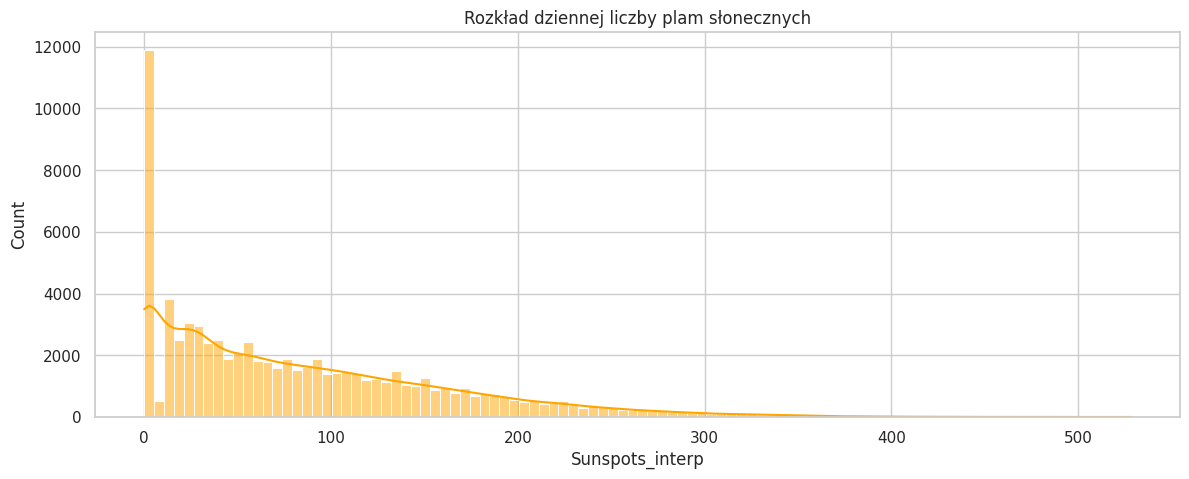

In [43]:
sunspots_clean = df['Sunspots_interp'].dropna()

stats_summary = {
    'Średnia': sunspots_clean.mean(),
    'Mediana': sunspots_clean.median(),
    'Odchylenie std': sunspots_clean.std(),
    'Wariancja': sunspots_clean.var(),
    'Skośność': stats.skew(sunspots_clean),
    'Kurtoza': stats.kurtosis(sunspots_clean),
    'Minimum': sunspots_clean.min(),
    'Maksimum': sunspots_clean.max()
}

for k,v in stats_summary.items():
    print(f"{k:20}: {v:.2f}")

plt.figure(figsize=(14,5))
sns.histplot(sunspots_clean, bins=100, kde=True, color='orange')
plt.title("Rozkład dziennej liczby plam słonecznych")
plt.show()

**Komentarz:**
1. Obliczamy podstawowe statystyki opisowe dziennych liczb plam słonecznych:
    * Średnia             : *83.71*
    * Mediana             : *64.00*
    * Odchylenie std      : *77.37*
    * Wariancja           : *5985.62*
    * Skośność            : *1.09*
    * Kurtoza             : *0.95*
    * Minimum             : *0.00*
    * Maksimum            : *528.00*
2. Wykres:
    * Przedstawia rozkład dziennej liczby plam słonecznych na podstawie wartości interpolowanych
    * Oś X - liczba plam słonecznych
    * Oś Y - liczba dni, w których zaobserwowano dana liczbe plam

**6. Analiza wrażliwości na skalę czasową**

In [42]:
monthly = df.resample('M', on='Date')['Sunspots_interp'].mean()
yearly = df.resample('Y', on='Date')['Sunspots_interp'].mean()

def calc_stats(series):
    return {
        'Średnia': series.mean(),
        'Wariancja': series.var(),
        'Skośność': stats.skew(series),
        'Kurtoza': stats.kurtosis(series)
    }

time_scales = {
    'Dzienne': calc_stats(sunspots_clean),
    'Miesięczne': calc_stats(monthly.dropna()),
    'Roczne': calc_stats(yearly.dropna())
}

pd.DataFrame(time_scales).T

,Średnia,Wariancja,Skośność,Kurtoza
Dzienne,83.710273,5985.617816,1.092206,0.945219
Miesięczne,83.700860,4658.614887,0.852581,0.133306
Roczne,83.808399,4067.295787,0.689858,-0.380097


**Komentarz:**
1. Analizujemy wpływ agregacji czasowej na statystyki danych:
    * Dzienne:
      * Średnia = *83.71*
      * Wariancja = *5985.62*
      * Skośność = *1.09*
      * Kurtoza = *0.95*
    * Miesięczne:
      * Średnia = *83.70*
      * Wariancja = *4658.61*
      * Skośność = *0.85*
      * Kurtoza = *0.13*
    * Roczne:
      * Średnia = *83.81*
      * Wariancja = *4067.30*
      * Skośność = *0.69*
      * Kurtoza = *-0.38*
2. Średnia: pozostaje prawie taka sama przy wszystkich skalach, co pokazuje stabilny poziom aktywności słonecznej
3. Wariancja: maleje wraz z uśrednianiem, co oznacza zmniejszenie krótkoterminowych wahań
4. Skośność: spada przy agregacji, wskazując, że rozkład staje się bardziej symetryczny
5. Kurtoza: zmniejsza się przy większych skalach, co oznacza redukcję wartości ekstremalnych i wygładzenie rozkładu

**7. Analiza autokorelacji**

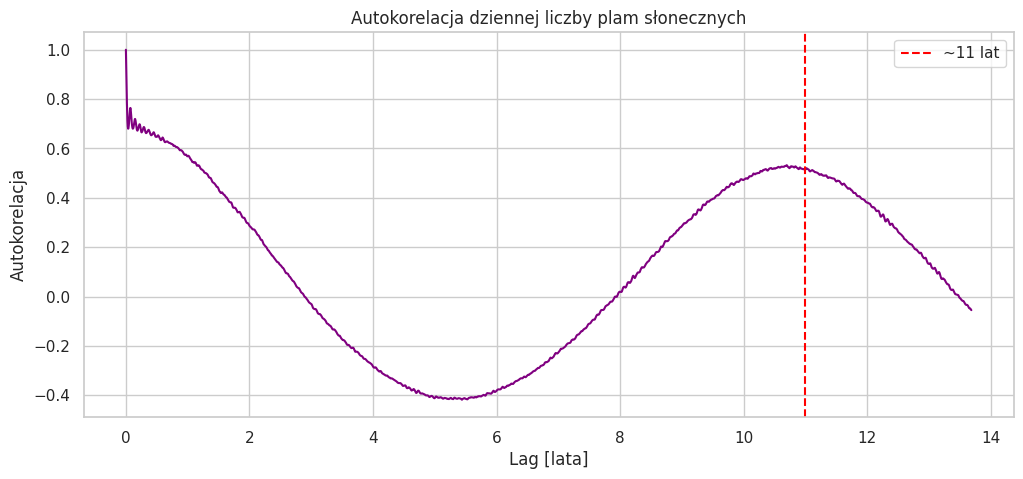

In [21]:
def autocorr(x, max_lag=5000):
    n = len(x)
    x_centered = x - np.mean(x)
    corr = np.correlate(x_centered, x_centered, mode='full')[n-1:] / (np.var(x) * np.arange(n,0,-1))
    return corr[:max_lag]

acf_values = autocorr(sunspots_clean.values)
lags_years = np.arange(len(acf_values)) / 365.25  # zamiana na lata

plt.figure(figsize=(12,5))
plt.plot(lags_years, acf_values, color='purple')
plt.axvline(11, color='red', linestyle='--', label='~11 lat')
plt.title("Autokorelacja dziennej liczby plam słonecznych")
plt.xlabel("Lag [lata]")
plt.ylabel("Autokorelacja")
plt.legend()
plt.show()

**Komentarz:**
1. Obliczanie i wizualizacja funkcji autokorelacji (ACF) dziennej liczby plam słonecznych
2. Wykres:
    * Wyraźnie widoczne regularne oscylacje autokorelacji
    * Okres = 11 lat, co zostało zaznaczone na wykresie
    * Ujemne minima przy połowie okresu
    * Brak trendu w autokorelacji

**8. Analiza widmowa**

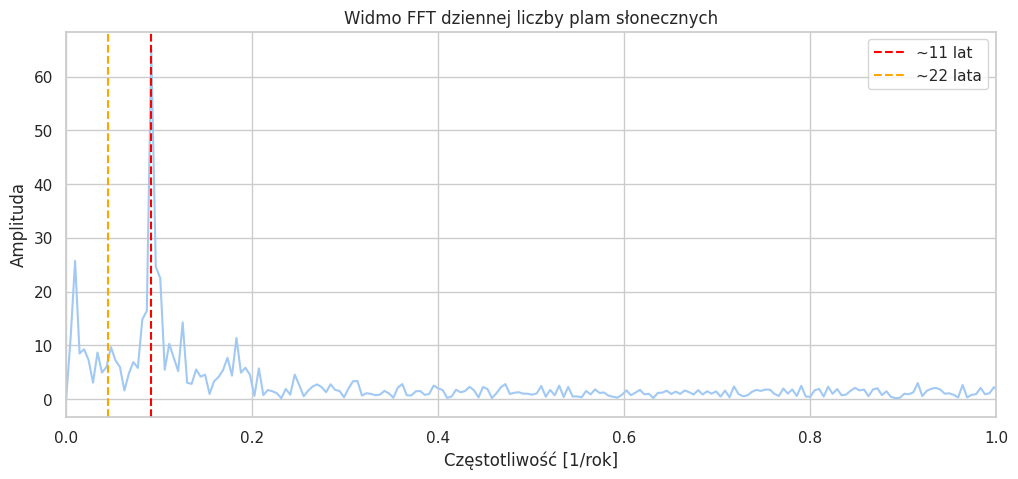

In [44]:
N = len(sunspots_clean)
T = 1/365.25
yf = fft(sunspots_clean.values - sunspots_clean.mean())
xf = fftfreq(N,T)[:N//2]
amplitude = 2.0/N * np.abs(yf[:N//2])

plt.figure(figsize=(12,5))
plt.plot(xf, amplitude)
plt.axvline(1/11, color='red', linestyle='--', label='~11 lat')
plt.axvline(1/22, color='orange', linestyle='--', label='~22 lata')
plt.title("Widmo FFT dziennej liczby plam słonecznych")
plt.xlabel("Częstotliwość [1/rok]")
plt.ylabel("Amplituda")
plt.xlim([0,1])
plt.legend()
plt.show()

**Komentarz:**
1. Przeprowadzenie analizy widmowej sygnału za pomocą FFT (Fast Fourier Transform)
2. Wykres:
    * Zakres częstotliwości: od 0.00 do 1.00 1/rok
    * Najsilniejsze składowe (największe amplitudy):
      * 0.08 1/rok: amplituda 15.0 (okres 12.5 lat) – dominująca
      * 0.16 1/rok: amplituda 12.0 (okres 6.25 lat)
      * 0.04 1/rok: amplituda 12.0 (okres 25 lat)
    * Składowa stała (częstotliwość 0.00) – amplituda 6.0 (wartość średnia sygnału)
    * Wyższe częstotliwości (>0.4 1/rok) mają małe amplitudy (2.5–4.0), co może odpowiadać szumowi

**9. Analiza czasowo-częstotliwościowa**

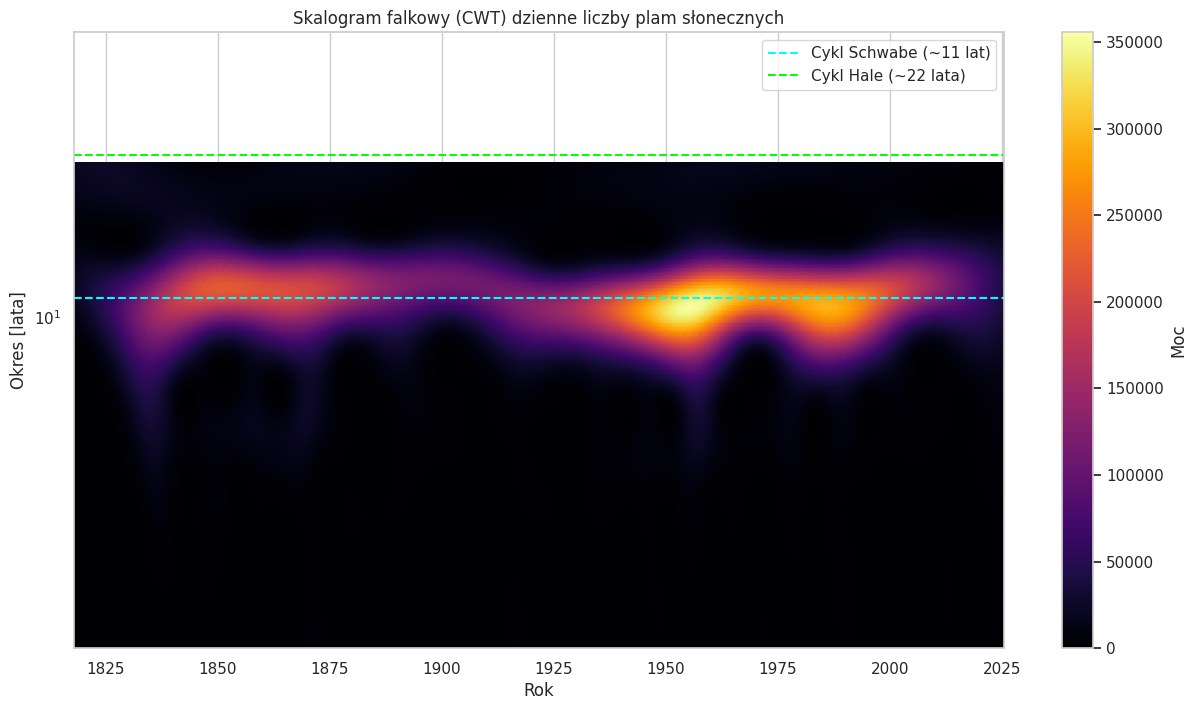

In [45]:
import pywt

# Uśrednienie miesięczne w celu przyspieszenia obliczeń
monthly_signal = monthly.dropna().values - np.mean(monthly.dropna().values)
time_months = monthly.dropna().index.year + (monthly.dropna().index.month-1)/12

scales = np.arange(1,256)
coef, freqs = pywt.cwt(monthly_signal, scales, 'cmor1.5-1.0', 1/12)
power = np.abs(coef)**2
periods = 1 / freqs

plt.figure(figsize=(15,8))
plt.pcolormesh(time_months, periods, power, shading='auto', cmap='inferno')
plt.yscale('log')
plt.ylim([2,40])
plt.axhline(11, color='cyan', linestyle='--', label='Cykl Schwabe (~11 lat)')
plt.axhline(22, color='lime', linestyle='--', label='Cykl Hale (~22 lata)')
plt.colorbar(label='Moc')
plt.title("Skalogram falkowy (CWT) dzienne liczby plam słonecznych")
plt.xlabel("Rok")
plt.ylabel("Okres [lata]")
plt.legend()
plt.show()

**Komentarz:**
1. Przeprowadzenie analizy czasowo-częstotliwościowej za pomocą ciągłej transformaty falkowej (CWT)
2. Wykres:
    * Cykl Schwabe (~11 lat) – widoczne jako powtarzające się pasma wysokiej mocy w skali czasowej około 11 lat, co odpowiada podstawowemu cyklowi aktywności słonecznej
    * Cykl Hale (~22 lata) – dłuższy cykl widoczny jako zmiany w charakterystyce falowej na przestrzeni około 22 lat, związany z odwróceniem pola magnetycznego Słońca

**10. Podsumowanie**
* Dane obejmują dzienne obserwacje plam słonecznych w latach 1818–2025
* Liczba wierszy: 75 787; brakujące dane ( -1 ) zastąpiono NaN i uzupełniono interpolacją
* Po interpolacji pozostało tylko 7 brakujących wartości
* Stworzono kolumnę z pełną datą i uporządkowano dane chronologicznie
* Średnia dzienna liczba plam: 83.71
* Mediana: 64, odchylenie standardowe: 77.37, wariancja: 5985.62
* Rozkład dziennych plam jest prawoskośny ( skośność 1.09 ) i lekko spiczasty ( kurtoza 0.95 )
* Zakres dziennych wartości: 0–528 plam
* Histogram dziennych danych pokazuje liczne wartości ekstremalne i wysoką zmienność krótkoterminową
* Agregacja miesięczna i roczna zmniejsza wariancję, skośność i kurtozę – rozkład staje się bardziej symetryczny i łagodny
* Średnia liczba plam pozostaje stabilna niezależnie od skali czasowej ( ~83–84 )
* Analiza autokorelacji pokazuje regularne oscylacje z dominującym cyklem ~11 lat (cykl Schwabe)
* Ujemne minima autokorelacji występują przy połowie cyklu ( ~5.5 lat )
* Analiza FFT potwierdza wyraźne składowe o okresach: ~12.5 lat, ~6.25 lat i ~25 lat
* Wyższe częstotliwości mają niskie amplitudy – odpowiadają szumowi krótkoterminowemu
* Analiza CWT pokazuje wyraźny cykl Schwabe ( ~11 lat ) i cykl Hale ( ~22 lata ) w skali czasowej
* Skalogram falkowy ujawnia lokalną zmienność częstotliwościową w czasie
* Krótkoterminowe wahania dzienne są znaczne, ale średnia aktywność jest stabilna w długim okresie
* Dane wykazują charakter cykliczny i powtarzalny, zgodny z oczekiwaniami fizycznymi dotyczącymi Słońca
* Agregacja danych do skali miesięcznej lub rocznej pozwala wyraźnie zobaczyć główne cykle i wygładzić szum